# Plot building energy
- This script is used to visualize space heating, and air-conditioning fluxes.
- Simulations: CNTL, TranAlbe

In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import string
home_path = '/gws/ssde/j25a/duicv/yuansun/'

In [2]:
scenario_list = ['cntl', 'tran_albe']
var_list = ['URBAN_AC', 'URBAN_HEAT']
varname_list = [r'$Q_\mathrm{ac}$', r'$Q_\mathrm{heat}$']
df_cntl = pd.read_csv('./data_for_figure/building_energy_consumption_HK_cntl.csv')
df_cntl['time'] = pd.to_datetime(df_cntl['time'])
df_cntl = df_cntl[df_cntl['time'].dt.year != 2034].copy()
df_cntl_slice = df_cntl[(df_cntl['time']<pd.to_datetime('2035-04-01'))].copy()
df_tran_albe = pd.read_csv('./data_for_figure/building_energy_consumption_HK_tran_albe.csv')
df_tran_albe['time'] = pd.to_datetime(df_tran_albe['time'])
df_tran_albe = df_tran_albe[df_tran_albe['time']>=pd.to_datetime('2035-04-01')].copy()
df_tran_albe = pd.concat([df_cntl_slice, df_tran_albe], ignore_index=True)
df_tran_albe = df_tran_albe.sort_values(by='time')
data_list = [df_cntl, df_tran_albe]
df_cntl.head()

,time,value (unit:W e6),var
198,2035-01-01 00:00:00,661.951253,WASTEHEAT
199,2035-01-01 00:00:00,3309.535001,URBAN_HEAT
200,2035-01-01 01:00:00,590.832493,WASTEHEAT
201,2035-01-01 01:00:00,2953.324488,URBAN_HEAT
202,2035-01-01 02:00:00,466.282886,WASTEHEAT


In [4]:
df_cntl_ac = df_cntl[df_cntl['var'] == 'URBAN_AC'].copy()
df_cntl_ac['year'] = df_cntl_ac['time'].dt.year
df_cntl_ac_yearly = df_cntl_ac[['value (unit:W e6)', 'year']].groupby('year').sum().copy()
df_cntl_heat = df_cntl[df_cntl['var'] == 'URBAN_HEAT'].copy()
df_cntl_heat['year'] = df_cntl_heat['time'].dt.year
df_cntl_heat_yearly = df_cntl_heat[['value (unit:W e6)', 'year']].groupby('year').sum().copy()
df_cntl_yearly = pd.merge(df_cntl_ac_yearly, df_cntl_heat_yearly, on='year', suffixes=('_AC', '_HEAT'))
df_cntl_yearly['value (unit:W e6)_TOTAL'] = df_cntl_yearly['value (unit:W e6)_AC'] + df_cntl_yearly['value (unit:W e6)_HEAT']
df_cntl_yearly

,value (unit:W e6)_AC,value (unit:W e6)_HEAT,value (unit:W e6)_TOTAL
year,,,
2035,8.675253e+06,379564.345171,9.054818e+06
2036,7.834794e+06,400357.394888,8.235152e+06
2037,8.207213e+06,192850.094304,8.400063e+06
2038,8.279297e+06,612843.965260,8.892141e+06
2039,8.112996e+06,116215.983435,8.229212e+06


In [8]:
df_tran_albe_ac = df_tran_albe[df_tran_albe['var'] == 'URBAN_AC'].copy()
df_tran_albe_ac['year'] = df_tran_albe_ac['time'].dt.year
df_tran_albe_ac_yearly = df_tran_albe_ac[['value (unit:W e6)', 'year']].groupby('year').sum()
df_tran_albe_heat = df_tran_albe[df_tran_albe['var'] == 'URBAN_HEAT'].copy()
df_tran_albe_heat['year'] = df_tran_albe_heat['time'].dt.year
df_tran_albe_heat_yearly = df_tran_albe_heat[['value (unit:W e6)', 'year']].groupby('year').sum()
df_tran_albe_yearly = pd.merge(df_tran_albe_ac_yearly, df_tran_albe_heat_yearly, on='year', suffixes=('_AC', '_HEAT'))
df_tran_albe_yearly['value (unit:W e6)_TOTAL'] = df_tran_albe_yearly['value (unit:W e6)_AC'] + df_tran_albe_yearly['value (unit:W e6)_HEAT']
df_tran_albe_yearly

,value (unit:W e6)_AC,value (unit:W e6)_HEAT,value (unit:W e6)_TOTAL
year,,,
2035,8.633538e+06,379993.510363,9.013531e+06
2036,7.760418e+06,403477.380294,8.163895e+06
2037,8.058865e+06,195220.263021,8.254086e+06
2038,8.089667e+06,619438.763022,8.709106e+06
2039,7.855992e+06,120109.381875,7.976101e+06


In [9]:
df_tran_albe_merge = df_tran_albe.merge(df_cntl, on=['time', 'var'], suffixes=('_tran_albe', '_cntl'))
df_tran_albe_merge['diff'] = df_tran_albe_merge['value (unit:W e6)_tran_albe'] - df_tran_albe_merge['value (unit:W e6)_cntl']
df_tran_albe_merge.set_index('time', inplace=True)
df_tran_albe_merge.head()

,value (unit:W e6)_tran_albe,var,value (unit:W e6)_cntl,diff
time,,,,
2035-01-01 00:00:00,661.951253,WASTEHEAT,661.951253,0.0
2035-01-01 00:00:00,3309.535001,URBAN_HEAT,3309.535001,0.0
2035-01-01 01:00:00,590.832493,WASTEHEAT,590.832493,0.0
2035-01-01 01:00:00,2953.324488,URBAN_HEAT,2953.324488,0.0
2035-01-01 02:00:00,466.282886,WASTEHEAT,466.282886,0.0


In [10]:
df_tran_albe_day = df_tran_albe.merge(df_cntl, on=['time', 'var'], suffixes=('_tran_albe', '_cntl')).copy()
df_tran_albe_day['date'] = df_tran_albe_day['time'].dt.date
df_tran_albe_day_sum = df_tran_albe_day.groupby(['date', 'var'])[['value (unit:W e6)_tran_albe', 'value (unit:W e6)_cntl']].sum().reset_index()
df_tran_albe_day_sum.rename(columns={'value (unit:W e6)_tran_albe': 'value (unit:Wh e6)_tran_albe', 
                                      'value (unit:W e6)_cntl': 'value (unit:Wh e6)_cntl'}, inplace=True)
df_tran_albe_day_sum['diff'] = df_tran_albe_day_sum['value (unit:Wh e6)_tran_albe'] - df_tran_albe_day_sum['value (unit:Wh e6)_cntl']
df_tran_albe_day_sum['year'] = pd.to_datetime(df_tran_albe_day_sum['date']).dt.year
df_tran_albe_day_sum['month_day'] = pd.to_datetime(df_tran_albe_day_sum['date']).dt.strftime('%m-%d')
df_tran_albe_day_sum['doy'] = pd.to_datetime(df_tran_albe_day_sum['date']).dt.dayofyear
df_tran_albe_day_sum

,date,var,value (unit:Wh e6)_tran_albe,value (unit:Wh e6)_cntl,diff,year,month_day,doy
0,2035-01-01,URBAN_HEAT,36734.334204,36734.334204,0.000000,2035,01-01,1
1,2035-01-01,WASTEHEAT,7346.978551,7346.978551,0.000000,2035,01-01,1
2,2035-01-02,URBAN_HEAT,22369.097678,22369.097678,0.000000,2035,01-02,2
3,2035-01-02,WASTEHEAT,4474.226801,4474.226801,0.000000,2035,01-02,2
4,2035-01-03,URBAN_HEAT,4272.071439,4272.071439,0.000000,2035,01-03,3
...,...,...,...,...,...,...,...,...
3905,2039-12-27,WASTEHEAT,648.180852,809.398075,-161.217224,2039,12-27,361
3906,2039-12-28,URBAN_AC,4386.744465,4977.542589,-590.798124,2039,12-28,362
3907,2039-12-28,WASTEHEAT,2631.646004,2986.585687,-354.939682,2039,12-28,362
3908,2039-12-29,URBAN_AC,5735.552994,6238.226305,-502.673311,2039,12-29,363


In [ ]:
fontsize = 6
labelsize = 6
lc1 = '#4daf4a'
lc2 = '#377eb8'
lc3 = '#ff7f00'
lc4 = '#e41a1c'
lc5 = '#984ea3'
lc_dict = {2035: lc1, 2036: lc2, 2037: lc3, 2038: lc4, 2039: lc5}
labelcolor = '#6b6b6b'
linewidth = 0.5
boundarywidth = 0.5
length = 4
pad = 1
ymin_list = [6, 0.1, -1.5, -0.1]
ymax_list = [10, 0.7, 1, 0.6]
handletextpad = 0.5
padding = 4
start_date = '01-01'
end_date = '12-31'
year_ranges = np.arange(2035, 2040)
rolling_window = 30

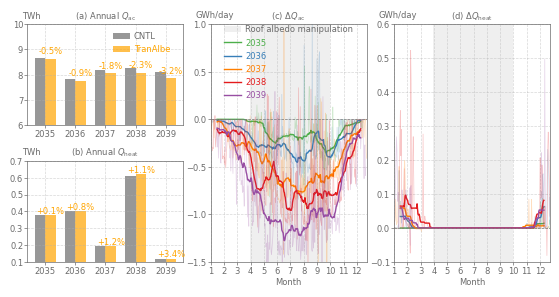

In [ ]:
fig = plt.figure(figsize=(5.5, 2.75))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 1])
ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[1, 0])   # bottom-left
ax3 = fig.add_subplot(gs[:, 1])
ax4 = fig.add_subplot(gs[:, 2])
ax = [ax3, ax4]
ax_bar = [ax1, ax2]
ax_all = [ax1, ax2, ax3, ax4]
for i in range(4):  
    ymin = ymin_list[i]
    ymax = ymax_list[i]  
    ax_all[i].set_ylim(ymin, ymax)
    if i >=2:
        ax_all[i].fill_between(range(3*31, 9*31+1), ymin, ymax, color=labelcolor, alpha=0.1, 
                               edgecolor='none', label='Roof albedo manipulation')
    ax_all[i].grid(True,linestyle='--',linewidth=0.5, alpha=0.5)
    ax_all[i].tick_params(axis='y', labelleft=True, labelsize=labelsize, length=length/2, pad=pad, width = boundarywidth,colors=labelcolor)
    ax_all[i].tick_params(axis='x', labelsize=labelsize, length=length/2, pad=pad, width = boundarywidth,colors=labelcolor)
    ax_all[i].set_ylabel(f'TWh', labelpad=5, rotation=0, ha='center', fontsize=fontsize, color=labelcolor)
    for spine in ax_all[i].spines.values():
        spine.set_linewidth(boundarywidth)
        spine.set_edgecolor(labelcolor)
var_label_list = ['AC', 'HEAT']
for i, var in enumerate(var_label_list):
    year_cntl_yearly = df_cntl_yearly[f'value (unit:W e6)_{var}']
    year_tran_albe_yearly = df_tran_albe_yearly[f'value (unit:W e6)_{var}']
    bar_width = 0.35
    x = np.arange(len(year_ranges))
    ax_bar[i].bar(x - bar_width/2, year_cntl_yearly/1e6, width=bar_width, label='CNTL', color=labelcolor, alpha=0.7)
    ax_bar[i].bar(x + bar_width/2, year_tran_albe_yearly/1e6, width=bar_width, label='TranAlbe', color='orange', alpha=0.7)
    ax_bar[i].set_title(f'({string.ascii_lowercase[i]}) Annual {varname_list[i]}', fontsize=fontsize, color=labelcolor, pad = padding)
    ax_bar[i].set_xticks(x)
    ax_bar[i].set_xticklabels(year_ranges)
    ax_bar[i].yaxis.set_label_coords(0.025, 1.04)
    percentage_change = ((year_tran_albe_yearly - year_cntl_yearly) / year_cntl_yearly * 100).round(2)
    if i ==1:
        sign = '+'
        yoffset = 0.01
    else:
        sign = ''  
        yoffset = 0.2   
    for j, (x_pos, y_val, pc) in enumerate(zip(x + bar_width/2, year_tran_albe_yearly/1e6, percentage_change)):
        ax_bar[i].text(x_pos, y_val + yoffset, f'{sign}{pc:.1f}%', fontsize=fontsize, color='orange', ha='center')   
lines_bar, labels_bar = ax_bar[0].get_legend_handles_labels()  
legend_bar = ax_bar[0].legend(bbox_to_anchor=(0.5, 1), loc='upper left', fontsize=fontsize, frameon=False, handletextpad=handletextpad, ncol=1)
for i, text in enumerate(legend_bar.get_texts()):
    text.set_color([labelcolor, 'orange'][i])
for i, var in enumerate(var_list):
    sel_var_df = df_tran_albe_day_sum[df_tran_albe_day_sum['var']==var]
    for year in year_ranges:
        sel_var_year_df = sel_var_df[sel_var_df['year']==year]
        year_color = lc_dict[year]
        ax[i].plot(sel_var_year_df['doy'], sel_var_year_df['diff']/1000, linewidth=linewidth, 
                   alpha=0.25, color=year_color)
        sel_var_year_complete = (sel_var_year_df.set_index('doy').reindex(range(1, 366)).fillna({'diff':0}).reset_index(names=['doy']))  
        sel_var_year_df_rolling = sel_var_year_complete.set_index('doy')['diff'].rolling(window=rolling_window, center=True).mean()
        ax[i].plot(sel_var_year_df_rolling.index, sel_var_year_df_rolling.values/1000, 
                   label=f'{year}', linewidth=1, color=year_color)
    varname = varname_list[i]
    ax[i].set_title(f'({string.ascii_lowercase[i+2]}) $\Delta${varname}', fontsize=fontsize, color=labelcolor, pad = padding)    
    ax[i].axhline(y=0, color='gray', linestyle='--', linewidth=linewidth)
    ax[i].set_xticks(range(1, 366, 31))
    ax[i].set_xlim(1, 365)
    xticks_labels = [str(int(m)) for m in pd.date_range(start='2024-01-01', end='2024-12-31', freq='MS').strftime('%m')]
    ax[i].set_xticklabels(xticks_labels)
    ax[i].set_xlabel('Month', fontsize=fontsize, color=labelcolor, labelpad=padding/2)
    ax[i].set_ylabel(f'GWh/day', labelpad=5, rotation=0, ha='center', fontsize=fontsize, color=labelcolor) # megawatt-hour, 10^6 watt-hour
    ax[i].yaxis.set_label_coords(0.025, 1.02)
lines, labels = ax[0].get_legend_handles_labels()  
legend = ax[0].legend(lines, labels, bbox_to_anchor=(0.5, 0.65), loc='lower center', frameon=False,
                        handletextpad=handletextpad, fontsize=labelsize, ncol=1)
for i, text in enumerate(legend.get_texts()):
    text.set_color([labelcolor, lc1, lc2, lc3, lc4, lc5][i])
plt.subplots_adjust(left=0.04, right=0.99, bottom=0.085, top=0.95, wspace=0.175, hspace=0.35) 
fig.savefig('energy_savings.png', dpi=300)
fig.savefig('energy_savings.pdf', dpi=600)

# Description

In [11]:
df_cntl_yearly_check = df_cntl_yearly.copy()
df_cntl_yearly_check = df_cntl_yearly_check/1e6
df_tran_albe_yearly_check = df_tran_albe_yearly.copy()
df_tran_albe_yearly_check = df_tran_albe_yearly_check/1e6
df_cntl_yearly_check['rate'] = 100 * (df_cntl_yearly_check['value (unit:W e6)_AC'] / df_cntl_yearly_check['value (unit:W e6)_TOTAL'])
df_cntl_yearly_check

,value (unit:W e6)_AC,value (unit:W e6)_HEAT,value (unit:W e6)_TOTAL,rate
year,,,,
2035,8.675253,0.379564,9.054818,95.808150
2036,7.834794,0.400357,8.235152,95.138433
2037,8.207213,0.192850,8.400063,97.704183
2038,8.279297,0.612844,8.892141,93.108027
2039,8.112996,0.116216,8.229212,98.587763


In [16]:
# energy for AC, coefficient is 0.6
e_ac = np.round(np.mean(df_cntl_yearly_check['value (unit:W e6)_AC'] * 0.6), 1) # 2035-2039 period average
e_ac

np.float64(4.9)

In [17]:
# energy for HEAT, coefficent is 1.2
e_heat = np.round(np.mean(df_cntl_yearly_check['value (unit:W e6)_HEAT'] * 1.2), 1) # 2035-2039 period average
e_heat 

np.float64(0.4)

In [39]:
ac_saving = (df_cntl_yearly_check['value (unit:W e6)_AC'] - df_tran_albe_yearly_check['value (unit:W e6)_AC']) * 0.6 # unit: terawatt-hour
ac_saving

year
2035    0.025029
2036    0.044626
2037    0.089008
2038    0.113778
2039    0.154202
Name: value (unit:W e6)_AC, dtype: float64

In [38]:
ds_mask_hk = xr.open_dataset(f'{home_path}0_wrf-cstm_GM-HK/HK/mask/mask_HK_lat_lon.nc')
ds_mask_hk_pct_urban = ds_mask_hk['PCT_URBAN']
ds_mask_hk_urban_area = ds_mask_hk_pct_urban * 1.44 
ds_mask_hk_urban_area_total = ds_mask_hk_urban_area.sum().item()
print(ds_mask_hk_urban_area_total) # km2

261.89304570370314


In [44]:
ac_saving.iloc[-1] * 1e6 / ds_mask_hk_urban_area_total # unit: watt-hour/m2

np.float64(588.7994983827587)